# Linear Regression Machine Learning Project for House Price Prediction

### Import Libraries

In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings('ignore')

### Preprocessing and Scaling.

In [68]:
HouseDF = pd.read_csv('Housing_Price_data_set.csv')
HouseDF = HouseDF.drop(['Unnamed: 0','driveway','recroom','fullbase','airco','prefarea', 'gashw'],axis=1)
mean = HouseDF.mean()[0]
stddev = HouseDF.std()[0]
data = (HouseDF - HouseDF.mean())/HouseDF.std()


In [69]:
HouseDF.head()

,price,lotsize,bedrooms,bathrms,stories,garagepl
0,42000.0,5850,3,1,2,1
1,38500.0,4000,2,1,1,0
2,49500.0,3060,3,1,1,0
3,60500.0,6650,3,1,2,0
4,61000.0,6360,2,1,1,0


In [70]:
HouseDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   price     546 non-null    float64
 1   lotsize   546 non-null    int64  
 2   bedrooms  546 non-null    int64  
 3   bathrms   546 non-null    int64  
 4   stories   546 non-null    int64  
 5   garagepl  546 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 25.7 KB


In [71]:
HouseDF.describe()

,price,lotsize,bedrooms,bathrms,stories,garagepl
count,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000
mean,68121.597070,5150.265568,2.965201,1.285714,1.807692,0.692308
std,26702.670926,2168.158725,0.737388,0.502158,0.868203,0.861307
min,25000.000000,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,49125.000000,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,62000.000000,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,82000.000000,6360.000000,3.000000,2.000000,2.000000,1.000000
max,190000.000000,16200.000000,6.000000,4.000000,4.000000,3.000000


In [72]:
HouseDF.columns

Index(['price', 'lotsize', 'bedrooms', 'bathrms', 'stories', 'garagepl'], dtype='object')

## Exploratory Data Analysis for House Price Prediction

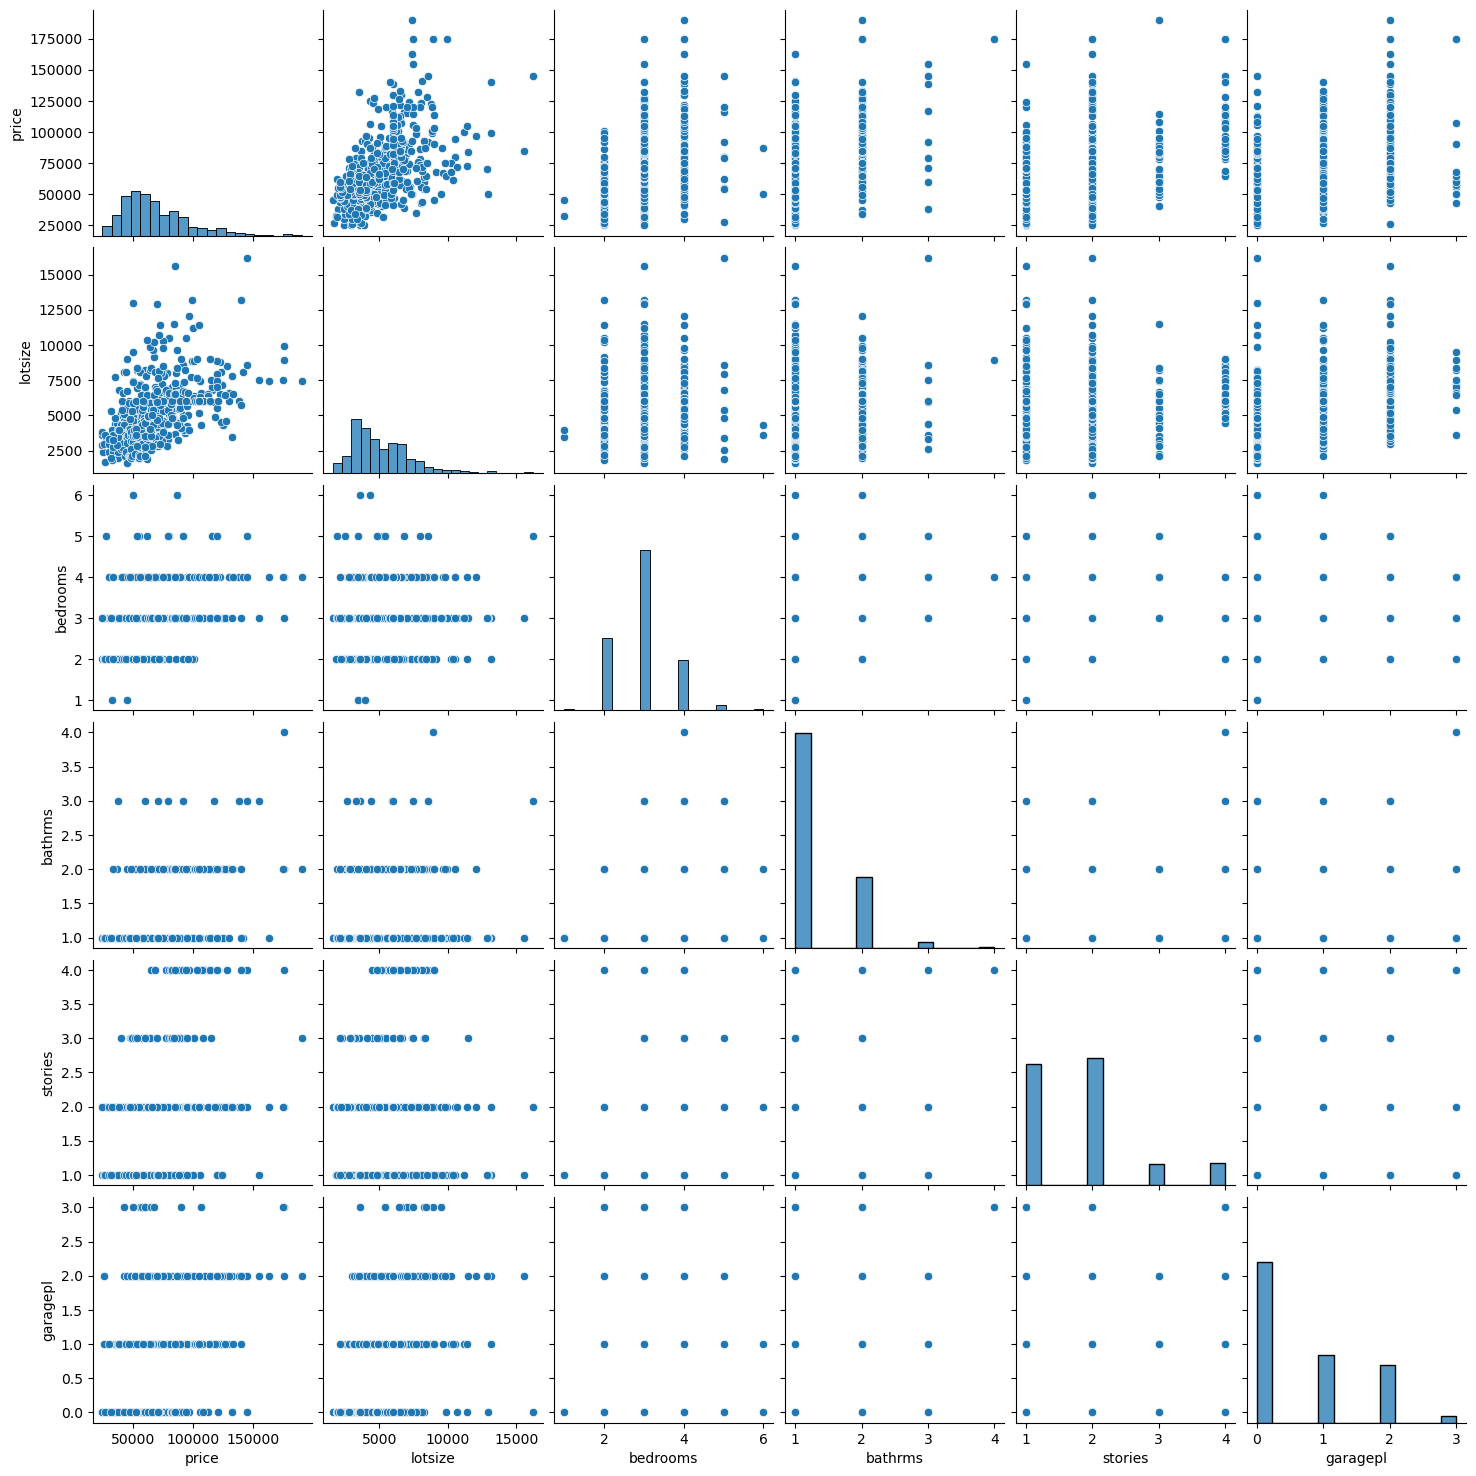

In [73]:
sns.pairplot(HouseDF)

<Axes: >

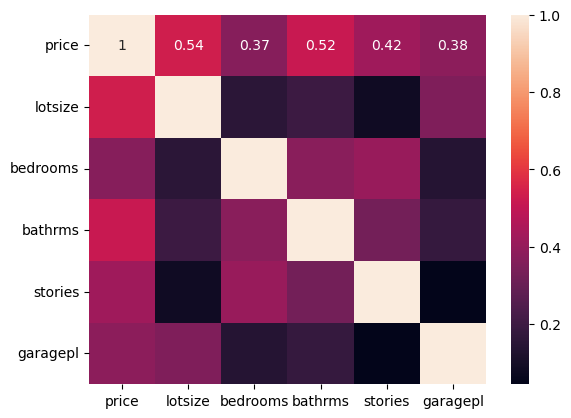

In [74]:
sns.heatmap(HouseDF.corr(), annot=True)

## Training a Linear Regression Model

### X and y List

In [75]:
X = HouseDF.iloc[:, :-1]
y = HouseDF.iloc[:, -1]

### Split Data into Train, Test

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [78]:
X_train

,price,lotsize,bedrooms,bathrms,stories
46,41000.0,3040,2,1,1
496,60000.0,4500,3,1,1
447,120000.0,5500,4,2,2
93,128000.0,8500,3,2,4
445,104900.0,11440,4,1,2
...,...,...,...,...,...
129,127000.0,4600,3,2,2
144,57250.0,4500,3,1,2
72,32500.0,1836,2,1,1
235,42500.0,4352,4,1,2


## Creating and Training the LinearRegression Model

In [79]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso

In [80]:
lm = LinearRegression()

In [81]:
lm.fit(X_train,y_train)

LinearRegression()

## LinearRegression Model Evaluation

In [82]:
print(lm.intercept_)

-0.21274258230700127


In [83]:
coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
price,0.000012
lotsize,0.000077
bedrooms,-0.084267
bathrms,0.048282
stories,-0.079694


## Predictions from our Linear Regression Model

In [84]:
predictions = lm.predict(X_test)

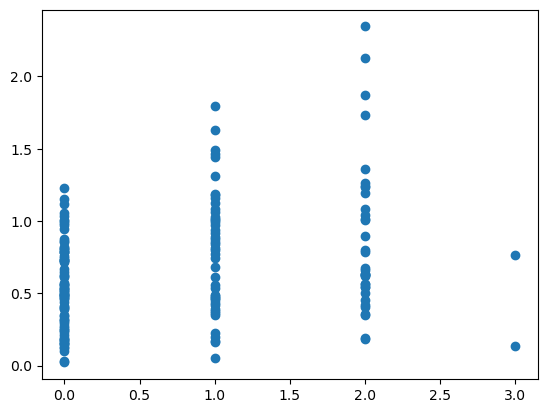

In [85]:
plt.scatter(y_test,predictions)

In [86]:
ridge = Ridge(alpha=1.0)  
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

In [87]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

In the above scatter plot, we see data is in line shape, which means our model has done good predictions.

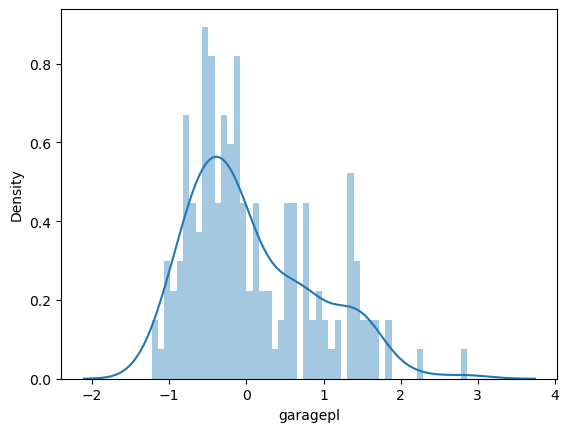

In [88]:
sns.distplot((y_test-predictions),bins=50);

In the above histogram plot, we see data is in bell shape (Normally Distributed), which means our model has done good predictions.

## Regression Evaluation Metrics

In [89]:
from sklearn import metrics

In [90]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 0.6500778491496764
MSE: 0.6553987640884772
RMSE: 0.8095670226043531


In [91]:
print('MAE:', metrics.mean_absolute_error(y_test, ridge_pred))
print('MSE:', metrics.mean_squared_error(y_test, ridge_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, ridge_pred)))

MAE: 0.650046346620387
MSE: 0.655197431913292
RMSE: 0.8094426674652703


In [92]:
print('MAE:', metrics.mean_absolute_error(y_test, lasso_pred))
print('MSE:', metrics.mean_squared_error(y_test, lasso_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, lasso_pred)))

MAE: 0.6489309113046577
MSE: 0.6467790980856887
RMSE: 0.8042257755665934
